**Group 2: Abijeet Dhillon, Noor Fatima, Tam Nguyen**

**Data Source**: https://databank.worldbank.org/source/world-development-indicators#advancedDownloadOptions  

**About the data**:  
The World Development Indicators (WDI) is the World Bank's primary collection of global development statistics, compiled from officially recognized international sources. It provides national, regional, and global estimates across economic, social, environmental, and institutional topics.  

**Our working subset:**

* Countries: 193 unique countries (of the ~217 available in WDI), after removing entities with no usable GDP data
* Indicators: 22 variables selected from the full WDI pool of ~1,498 series, covering energy, economic development, population, technology, trade, and environmental indicators
* Time coverage: 2006–2021 (16 years), narrowed down from the full ~ 1960–2025 range after finding that missingness stays roughly stable (~10%) through 2021 but rises sharply (>20%) afterward
* Format: Panel data — one row per country-year, reshaped from the original wide country-indicator-year layout into a long/tidy format for analysis
Resulting shape: ~3,400 country-year observations × 22 variables

# **Potential Questions**

**Economic development and  Energy Resources**
* How does energy use per capita relate to GDP per capita — does energy use continue to increase as countries become wealthier, or does it level off?
* How does dependence on energy imports relate to economic growth — do countries that rely more heavily on imported energy show different growth patterns?
* Do countries with higher natural-resource rents have higher GDP per capita, or is resource dependence unrelated to economic development
* Do countries with increasing electricity access also experience higher GDP per capita growth?

**Urbanization and Energy use**
* How does urbanization correlate with CO2 emissions per capita — does it rise together or decouple in wealthier countries?
* How does urbanization relate to energy use per capita — is the relationship different between lower-income and wealthier countries?

**Economic Development and CO2**
* How does energy use per capita relate to CO2 emissions — do countries with higher renewable energy use show a different relationship?
* How does GDP per capita relate to CO2 emissions per capita — do emissions continue to increase at higher income levels or begin to level off?
* Does greater renewable energy consumption correspond to lower CO2 emissions — and is this relationship different in wealthier countries?

# **ML Question: Can energy, economic, infrastructure, urbanization, and environmental indicators in one year predict a country's GDP per capita in the following year?**




In [ ]:
# Import python libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Data collection

##Import data into colaboratory.

In [ ]:
# Connect with GG Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Import the csv file
file_path = "/content/drive/MyDrive/Colab Notebooks/UoC/DATA601_Project/Data.xlsx"

df = pd.read_excel(file_path)

df.head()

,Country Name,Country Code,Series Name,Series Code,2006 [YR2006],2007 [YR2007],2008 [YR2008],2009 [YR2009],2010 [YR2010],2011 [YR2011],...,2016 [YR2016],2017 [YR2017],2018 [YR2018],2019 [YR2019],2020 [YR2020],2021 [YR2021],2022 [YR2022],2023 [YR2023],2024 [YR2024],2025 [YR2025]
0,Afghanistan,AFG,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,5.357403,13.826320,3.924984,21.390528,14.362441,0.426355,...,2.260314,2.647003,1.189228,3.911603,-2.351101,-20.738839,-6.240172,2.266944,1.873193,NaN
1,Afghanistan,AFG,"GDP per capita, PPP (constant 2021 internation...",NY.GDP.PCAP.PP.KD,1929.723897,2155.353068,2191.504356,2565.022086,2848.586061,2757.052587,...,2958.785399,2952.998916,2902.392113,2927.245144,2769.685745,2144.166570,1981.710168,1983.812620,1964.452289,NaN
2,Afghanistan,AFG,GDP per capita growth (annual %),NY.GDP.PCAP.KD.ZG,1.132485,11.692303,1.677279,17.043896,11.055031,-3.213295,...,-0.300121,-0.195570,-1.713743,0.856295,-5.382515,-22.584482,-7.576669,0.106093,-0.975915,NaN
3,Afghanistan,AFG,"Energy imports, net (% of energy use)",EG.IMP.CONS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,AFG,Energy intensity level of primary energy (MJ/$...,EG.EGY.PRIM.PP.KD,1.500000,1.540000,1.950000,2.270000,2.630000,3.250000,...,2.210000,2.270000,2.400000,2.370000,2.540000,2.940000,NaN,NaN,NaN,NaN


##Determine the types of data

In [ ]:
# Get information about the dataset
print("Dataset shape:")
print(df.shape)

print("\nData types:")
print(df.dtypes)

print("\nNumber of unique countries:")
print(df["Country Name"].nunique())

print("\nUnique countries:")
print(df["Country Name"].unique())

Dataset shape:
(5208, 24)

Data types:
Country Name      object
Country Code      object
Series Name       object
Series Code       object
2006 [YR2006]    float64
2007 [YR2007]    float64
2008 [YR2008]    float64
2009 [YR2009]    float64
2010 [YR2010]    float64
2011 [YR2011]    float64
2012 [YR2012]    float64
2013 [YR2013]    float64
2014 [YR2014]    float64
2015 [YR2015]    float64
2016 [YR2016]    float64
2017 [YR2017]    float64
2018 [YR2018]    float64
2019 [YR2019]    float64
2020 [YR2020]    float64
2021 [YR2021]    float64
2022 [YR2022]    float64
2023 [YR2023]    float64
2024 [YR2024]    float64
2025 [YR2025]    float64
dtype: object

Number of unique countries:
217

Unique countries:
['Afghanistan' 'Albania' 'Algeria' 'American Samoa' 'Andorra' 'Angola'
 'Antigua and Barbuda' 'Argentina' 'Armenia' 'Aruba' 'Australia' 'Austria'
 'Azerbaijan' 'Bahamas, The' 'Bahrain' 'Bangladesh' 'Barbados' 'Belarus'
 'Belgium' 'Belize' 'Benin' 'Bermuda' 'Bhutan' 'Bolivia'
 'Bosnia and Herzeg

## Data Cleaning/Reformating

In [ ]:
# Check for duplicated values
df.duplicated().sum()

np.int64(0)

###Remove unnecessary columns (Country code and Series Code)

In [ ]:
df = df.drop(columns=["Country Code", "Series Code"])

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (5208, 22)


,Country Name,Series Name,2006 [YR2006],2007 [YR2007],2008 [YR2008],2009 [YR2009],2010 [YR2010],2011 [YR2011],2012 [YR2012],2013 [YR2013],...,2016 [YR2016],2017 [YR2017],2018 [YR2018],2019 [YR2019],2020 [YR2020],2021 [YR2021],2022 [YR2022],2023 [YR2023],2024 [YR2024],2025 [YR2025]
0,Afghanistan,GDP growth (annual %),5.357403,13.826320,3.924984,21.390528,14.362441,0.426355,12.752287,5.600745,...,2.260314,2.647003,1.189228,3.911603,-2.351101,-20.738839,-6.240172,2.266944,1.873193,NaN
1,Afghanistan,"GDP per capita, PPP (constant 2021 internation...",1929.723897,2155.353068,2191.504356,2565.022086,2848.586061,2757.052587,2985.319145,3046.579931,...,2958.785399,2952.998916,2902.392113,2927.245144,2769.685745,2144.166570,1981.710168,1983.812620,1964.452289,NaN
2,Afghanistan,GDP per capita growth (annual %),1.132485,11.692303,1.677279,17.043896,11.055031,-3.213295,8.279369,2.052068,...,-0.300121,-0.195570,-1.713743,0.856295,-5.382515,-22.584482,-7.576669,0.106093,-0.975915,NaN
3,Afghanistan,"Energy imports, net (% of energy use)",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,Energy intensity level of primary energy (MJ/$...,1.500000,1.540000,1.950000,2.270000,2.630000,3.250000,2.600000,2.440000,...,2.210000,2.270000,2.400000,2.370000,2.540000,2.940000,NaN,NaN,NaN,NaN


###Reshape the data for easier analysis

In [ ]:
# Convert year to rows
df_long = df.melt(
    id_vars=["Country Name", "Series Name"],
    var_name="Year",
    value_name="Value"
)

df_long["Year"] = (
    df_long["Year"]
    .str.extract(r"(\d{4})")[0]                        # 2011 [YR2011] -> 2011
    .astype(int)                                       # Convert to int for easier filter later
)

df_long.head()

,Country Name,Series Name,Year,Value
0,Afghanistan,GDP growth (annual %),2006,5.357403
1,Afghanistan,"GDP per capita, PPP (constant 2021 internation...",2006,1929.723897
2,Afghanistan,GDP per capita growth (annual %),2006,1.132485
3,Afghanistan,"Energy imports, net (% of energy use)",2006,NaN
4,Afghanistan,Energy intensity level of primary energy (MJ/$...,2006,1.500000


In [ ]:
# Convert indicators from rows to columns
df_reshape = df_long.pivot(
    index=["Country Name", "Year"],
    columns="Series Name",
    values="Value"
).reset_index()

df_reshape.columns.name = None                # Remove the extra label above the columns

df_reshape.head()

,Country Name,Year,Access to electricity (% of population),Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita),Electric power consumption (kWh per capita),"Energy imports, net (% of energy use)",Energy intensity level of primary energy (MJ/$2021 PPP GDP),Energy use (kg of oil equivalent per capita),Fossil fuel energy consumption (% of total),GDP growth (annual %),...,"Manufacturing, value added (% of GDP)",Population density (people per sq. km of land area),Population growth (annual %),Renewable energy consumption (% of total final energy consumption),Rural population (% of total population),Rural population growth (annual %),Total natural resources rents (% of GDP),Trade (% of GDP),Urban population (% of total population),Urban population growth (annual %)
0,Afghanistan,2006,33.5,0.055794,NaN,NaN,1.50,NaN,NaN,5.357403,...,16.385537,38.980258,4.092702,31.9,79.889547,3.587604,0.504174,NaN,20.110453,6.124807
1,Afghanistan,2007,38.4,0.079669,NaN,NaN,1.54,NaN,NaN,13.826320,...,17.747310,39.725023,1.892598,28.8,79.409342,1.289695,0.449501,NaN,20.590658,4.252381
2,Afghanistan,2008,42.4,0.147376,NaN,NaN,1.95,NaN,NaN,3.924984,...,17.839116,40.603195,2.186546,21.2,78.875852,1.512458,0.601666,NaN,21.124148,4.744478
3,Afghanistan,2009,48.3,0.224491,NaN,NaN,2.27,NaN,NaN,21.390528,...,13.149877,42.111067,3.646381,16.5,78.311452,2.928255,0.424658,NaN,21.688548,6.283131
4,Afghanistan,2010,42.7,0.278192,NaN,NaN,2.63,NaN,NaN,14.362441,...,12.522577,43.365207,2.934687,15.2,77.738520,2.200387,0.625333,NaN,22.261480,5.542043


In [ ]:
# Dataset information after reformating
print("Dataset shape:")
print(df_reshape.shape)

print("\nNumber of countries:")
print(df_reshape["Country Name"].nunique())

print("\nData types:")
print(df_reshape.dtypes)

Dataset shape:
(4340, 26)

Number of countries:
217

Data types:
Country Name                                                                   object
Year                                                                            int64
Access to electricity (% of population)                                       float64
Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita)    float64
Electric power consumption (kWh per capita)                                   float64
Energy imports, net (% of energy use)                                         float64
Energy intensity level of primary energy (MJ/$2021 PPP GDP)                   float64
Energy use (kg of oil equivalent per capita)                                  float64
Fossil fuel energy consumption (% of total)                                   float64
GDP growth (annual %)                                                         float64
GDP per capita growth (annual %)                                           

###Treating Missing Values

In [ ]:
# Check missing data by years
missing_data = df_reshape.isna()
missing_data["Year"] = df_reshape["Year"]

missing_by_year = missing_data.groupby("Year").sum()                    # Count missing values by year
missing_by_year["Total Missing"] = missing_by_year.sum(axis=1)          # Add total missing values for each year

number_indicators = len(df_reshape.columns) - 2                         # Number of indicators (not include Country Name and Year)
number_countries = df_reshape["Country Name"].nunique()                 # Number of countries
total_values = number_indicators * number_countries                     # Total values in one year

missing_by_year["Missing Percentage"] = (missing_by_year["Total Missing"] / total_values) * 100         # Calculate percentage of missing values

missing_by_year

,Country Name,Access to electricity (% of population),Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita),Electric power consumption (kWh per capita),"Energy imports, net (% of energy use)",Energy intensity level of primary energy (MJ/$2021 PPP GDP),Energy use (kg of oil equivalent per capita),Fossil fuel energy consumption (% of total),GDP growth (annual %),GDP per capita growth (annual %),...,Population growth (annual %),Renewable energy consumption (% of total final energy consumption),Rural population (% of total population),Rural population growth (annual %),Total natural resources rents (% of GDP),Trade (% of GDP),Urban population (% of total population),Urban population growth (annual %),Total Missing,Missing Percentage
Year,,,,,,,,,,,,,,,,,,,,,
2006,0,5,14,68,87,19,40,51,13,13,...,0,7,0,11,11,42,0,0,573,11.002304
2007,0,3,14,68,87,19,40,50,12,12,...,0,7,0,11,11,41,0,0,555,10.656682
2008,0,3,14,68,86,19,68,77,11,11,...,0,7,0,11,10,38,0,0,593,11.386329
2009,0,2,14,68,84,19,68,76,8,8,...,0,7,0,11,10,38,0,0,576,11.059908
2010,0,2,14,68,83,19,68,80,7,7,...,0,7,0,12,10,38,0,0,574,11.021505
2011,0,2,14,68,84,18,68,76,7,7,...,0,7,0,12,7,38,0,0,555,10.656682
2012,0,2,14,67,81,16,67,74,8,8,...,0,5,0,12,9,38,0,0,547,10.503072
2013,0,2,14,67,80,16,67,77,8,8,...,0,5,0,12,7,36,0,0,542,10.407066
2014,0,2,14,67,81,16,67,77,7,7,...,0,5,0,12,6,34,0,0,537,10.311060


The missing percentage is relatively stable from 2006 to 2021 (~10%) but increases sharply after 2021 (>20%). Therefore, we will focus on the 2006–2021 period, where the data coverage is more consistent.

In [ ]:
df_final = df_reshape[df_reshape["Year"].between(2006, 2021)].copy()
df_final.head()

,Country Name,Year,Access to electricity (% of population),Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita),Electric power consumption (kWh per capita),"Energy imports, net (% of energy use)",Energy intensity level of primary energy (MJ/$2021 PPP GDP),Energy use (kg of oil equivalent per capita),Fossil fuel energy consumption (% of total),GDP growth (annual %),...,"Manufacturing, value added (% of GDP)",Population density (people per sq. km of land area),Population growth (annual %),Renewable energy consumption (% of total final energy consumption),Rural population (% of total population),Rural population growth (annual %),Total natural resources rents (% of GDP),Trade (% of GDP),Urban population (% of total population),Urban population growth (annual %)
0,Afghanistan,2006,33.5,0.055794,NaN,NaN,1.50,NaN,NaN,5.357403,...,16.385537,38.980258,4.092702,31.9,79.889547,3.587604,0.504174,NaN,20.110453,6.124807
1,Afghanistan,2007,38.4,0.079669,NaN,NaN,1.54,NaN,NaN,13.826320,...,17.747310,39.725023,1.892598,28.8,79.409342,1.289695,0.449501,NaN,20.590658,4.252381
2,Afghanistan,2008,42.4,0.147376,NaN,NaN,1.95,NaN,NaN,3.924984,...,17.839116,40.603195,2.186546,21.2,78.875852,1.512458,0.601666,NaN,21.124148,4.744478
3,Afghanistan,2009,48.3,0.224491,NaN,NaN,2.27,NaN,NaN,21.390528,...,13.149877,42.111067,3.646381,16.5,78.311452,2.928255,0.424658,NaN,21.688548,6.283131
4,Afghanistan,2010,42.7,0.278192,NaN,NaN,2.63,NaN,NaN,14.362441,...,12.522577,43.365207,2.934687,15.2,77.738520,2.200387,0.625333,NaN,22.261480,5.542043


In [ ]:
df_final.shape

(3472, 26)

Remove countries with no values either in GDP per capita OR GDP growth because we will use GDP as our predicted values in our ML model later


In [ ]:
# Group by countries that are missing any values in GDP per capita OR GDP growth
country_check = (df_final[['GDP per capita, PPP (constant 2021 international $)','GDP growth (annual %)']]
                 .isna()
                 .groupby(df_final["Country Name"])
                 .any())

# Find countries missing values in EITHER values either in GDP per capita OR GDP growth
countries_to_remove = country_check[country_check['GDP per capita, PPP (constant 2021 international $)'] |
                                    country_check['GDP growth (annual %)']
                                    ].index

print("Countries to remove:")
print(countries_to_remove.tolist())

print("\nNumber of countries to remove:", len(countries_to_remove))

# Calculate the percentage of removed rows/orginal rows
percentage_removed = (df_final[df_final["Country Name"].isin(countries_to_remove)].shape[0]/len(df_final)) * 100

print("Total rows before:", len(df_final))
print("Rows to remove:", df_final[df_final["Country Name"].isin(countries_to_remove)].shape[0])
print("Percentage of rows removed:", round(percentage_removed, 2), "%")

# Copy to dataframe contains countries not in list to remove
df_final = df_final[~df_final["Country Name"].isin(countries_to_remove)].copy()
df_final.shape

Countries to remove:
['American Samoa', 'British Virgin Islands', 'Cayman Islands', 'Channel Islands', 'Cuba', 'Djibouti', 'Eritrea', 'Faroe Islands', 'French Polynesia', 'Gibraltar', 'Guam', 'Isle of Man', "Korea, Dem. People's Rep.", 'Kosovo', 'Liechtenstein', 'Monaco', 'New Caledonia', 'Northern Mariana Islands', 'Sint Maarten (Dutch part)', 'South Sudan', 'St. Martin (French part)', 'Turks and Caicos Islands', 'Venezuela, RB', 'Yemen, Rep.']

Number of countries to remove: 24
Total rows before: 3472
Rows to remove: 384
Percentage of rows removed: 11.06 %


(3088, 26)

For Part 1, our group will leave missing values as NA because our main goal is to explore the data and examine relationships and correlations using the available observations. We don’t want to create too much synthetic data at this stage. In addition, for the ML model, GDP will be our target variable (Y), while the other selected variables will be predictors (X). For the next assignment, once we decide on the final model and predictor variables, we will handle the missing values in X based on the requirements of the selected model.

In [ ]:
# Count missing values for each variable from highest to lowest
missing_by_variable = pd.DataFrame({"Missing Values": df_final.isna().sum(),
                                    "Missing Percentage": df_final.isna().mean() * 100
                                    })

missing_by_variable = missing_by_variable.sort_values("Missing Percentage",ascending=False)

missing_by_variable

,Missing Values,Missing Percentage
"Energy imports, net (% of energy use)",994,32.189119
Fossil fuel energy consumption (% of total),840,27.202073
Electric power consumption (kWh per capita),816,26.424870
Energy use (kg of oil equivalent per capita),762,24.676166
Gross capital formation (% of GDP),440,14.248705
Trade (% of GDP),371,12.014249
"Inflation, consumer prices (annual %)",209,6.768135
"Manufacturing, value added (% of GDP)",190,6.152850
Individuals using the Internet (% of population),117,3.788860
Rural population growth (annual %),108,3.497409


In [ ]:
# Save reformated data to file CSV
from google.colab import drive
drive.mount('/content/drive')

df_final.to_csv(
    "/content/drive/MyDrive/Colab Notebooks/UoC/DATA601_Project/df_final.csv",
    index=False
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Reload dataset
from google.colab import drive
drive.mount("/content/drive")
file_path = "/content/drive/MyDrive/Colab Notebooks/UoC/DATA601_Project/df_final.csv"
df_final = pd.read_csv(file_path)
print(df_final.shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
(3088, 26)


# 2. Provide summary stats for key variables and interpretation

- Correctly computes
stats (mean, median,
sd, min/max, counts)
for at least two
variables.
- Concise, accurate
interpretation of
findings

GDP per capita has a mean of ~24,156 international dollars and a median of 14,854. The mean is much higher than the median, suggesting some countries have much higher GDP per capita than others. The values range from approximately 858 to 174,570 international dollars, showing large differences in economic development across countries.

In [ ]:
df_final['GDP per capita, PPP (constant 2021 international $)'].describe()

,"GDP per capita, PPP (constant 2021 international $)"
count,3088.000000
mean,24156.578901
std,25565.400165
min,857.993656
25%,5363.633069
50%,14854.739387
75%,35038.560731
max,174569.523171


On average, energy use is about 2,455 kg of oil equivalent per person, while the median is about 1,441. The large standard deviation (~2,966) and wide range (from ~9.7 to ~21,456) show that energy consumption varies greatly across countries.

In [ ]:
df_final['Energy use (kg of oil equivalent per capita)'].describe()

,Energy use (kg of oil equivalent per capita)
count,2326.000000
mean,2455.330469
std,2966.657216
min,9.727288
25%,573.126249
50%,1441.102301
75%,2967.027201
max,21456.066928


On average, about 82% of the population has access to electricity, while the median is 99%. This suggests that many countries are close to 100% electricity access, while a few countries with low electricity access make the average lower. The wide range from 1.3% to 100% and the standard deviation of about 28% also show a large gap in electricity access across countries.

In [ ]:
df_final['Access to electricity (% of population)'].describe()

,Access to electricity (% of population)
count,3087.000000
mean,81.982151
std,28.024872
min,1.300000
25%,70.550000
50%,99.000000
75%,100.000000
max,100.000000


CO₂ emissions have a mean of ~5.05 tonnes per person and a median of ~2.4 tonnes. The mean is higher than the median, suggesting that some countries have much higher CO₂ emissions than others. The values range from 0 to ~202.87 tonnes per person, and the standard deviation is about 9.22, showing large differences in CO₂ emissions across countries.

In [ ]:
df_final['Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita)'].describe()

,Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita)
count,2992.000000
mean,5.051814
std,9.221021
min,0.000000
25%,0.626825
50%,2.439964
75%,6.395753
max,202.865184


Electric power consumption has a mean of ~4,222 kWh per person and a median of ~2,330 kWh. The mean is much higher than the median, suggesting that some countries have much higher electricity consumption per person than others. The values range from about 5 to 55,085 kWh per person, and the standard deviation is about 5,909 kWh, showing large differences in electricity consumption across countries.

In [ ]:
df_final['Electric power consumption (kWh per capita)'].describe()

,Electric power consumption (kWh per capita)
count,2272.000000
mean,4222.107839
std,5908.728427
min,5.441591
25%,712.425580
50%,2330.044159
75%,5607.101645
max,55085.168448


On average, about 59% of the population lives in urban areas, while the median is about 61%. The mean and median are relatively similar, suggesting that the distribution is fairly balanced. Urban population ranges from about 9.5% to 100%, with a standard deviation of about 23%, showing substantial differences in urbanization across countries.

In [ ]:
df_final['Urban population (% of total population)'].describe()

,Urban population (% of total population)
count,3088.000000
mean,59.102929
std,23.264117
min,9.464629
25%,40.002780
50%,60.675955
75%,77.656765
max,100.000000


# 3. Visualize variable distributions

- Multiple, appropriate
visualizations (e.g.,
histograms, boxplots)
- Correct labeling, clear
presentation, good use
of libraries.

Q1: Explain your choice of plots using the five visualization components:

* Data component -- what kinds of data are you dealing with?
* Graphical component -- what kinds of plot can you use?
* Label component -- what should be on the plot axis?
* Esthetic component -- what should you plot say, and how best to do this?
* Ethical component -- Is the graph misleading, what is left out


Mentions potential biases/limitations.




## Data Component
Our data contains around 3400 observations from 193 unqiue countries, with a focus on the years 2005 to 2021. For each country and year, we have 26 variables the cover a range of economic statistics such as energy, economic development, population, technology, trade, and environmental indicators. The dataset mainly consists of quantitative continuous data, with a couple of categorical, temporal, percentage-based, and index variables.

## Graphical Component

For our data, we can utilize several types of plots. Some of the most prominent will be listed below, however this list is not exhaustive:
- One of them being a histogram to show the distribution of the GDP per capita, CO2 emissions, or energy use by country. These histogram plots can help show whether the data is skewed and if any values are unusual.
- Scatter plots are also helpful to examine the relationships between two numerical variables and determine outliers within our dataset. We could plot a scatter plot of the GDP per capita against the CO2 emissions per capita to determine if countries with higher or lower income levels have different leels of CO2 emissions. We could also plot electricity access against internet usage to determine an association.
- Another type of plot that could be appropriate is a box plot. We can utilize box plots to our mean, median, quartiles, and outliers to see which points are contributing to the distribution of our data being skewed. Some examples of these plots could be the electric power consumption per capita by year, the GDP per capita by year, or the CO2 emissions per capita by year.

## Label Component
The axes of our plots should be clearly definded and identify which variables an axis is displaying, along with the units. For example, if we were to plot a scatter plot examining economic development and CO2 emissions:
- X-axis: GDP per capita ($)
- Y-axis: CO2 emissions per capita (tons)

Our titles should also explain what our plots are trying to show, with which values of the variables are being plotted and their units.

## Esthetic Component

Our plots should clearly communicate patterns and relationships (if applicable). For example, our scatter plot of GDP per capita and CO2 emissions should make it easy for someone to look at the plot and determine whether there is a positive, negative, or weak relationship. For our plots that display our data's distribution, they should make the skewedness and outliers visible. We can do this by ensuring our scale is appropriate (with properly defined x-limits and y-limits) to ensure we include the whole plot, and a legend when needed.

## Ethical Component & Biases/Limitations

There are a few ways our data could come off as mis-leading on a graph that could lead to potential biases/limitations, if not properly dealt with:
- features with high levels of missing data may be non-representative of actual values
- countries with high income, energy use, or emissions may skew the distribution of some graphs
- major economic events (e.g. 2008 recession) may affect particular years
- the dataset is compiled over 193 countries over time which means that observations aren't independent
- countries may differ in their data quality and definitions

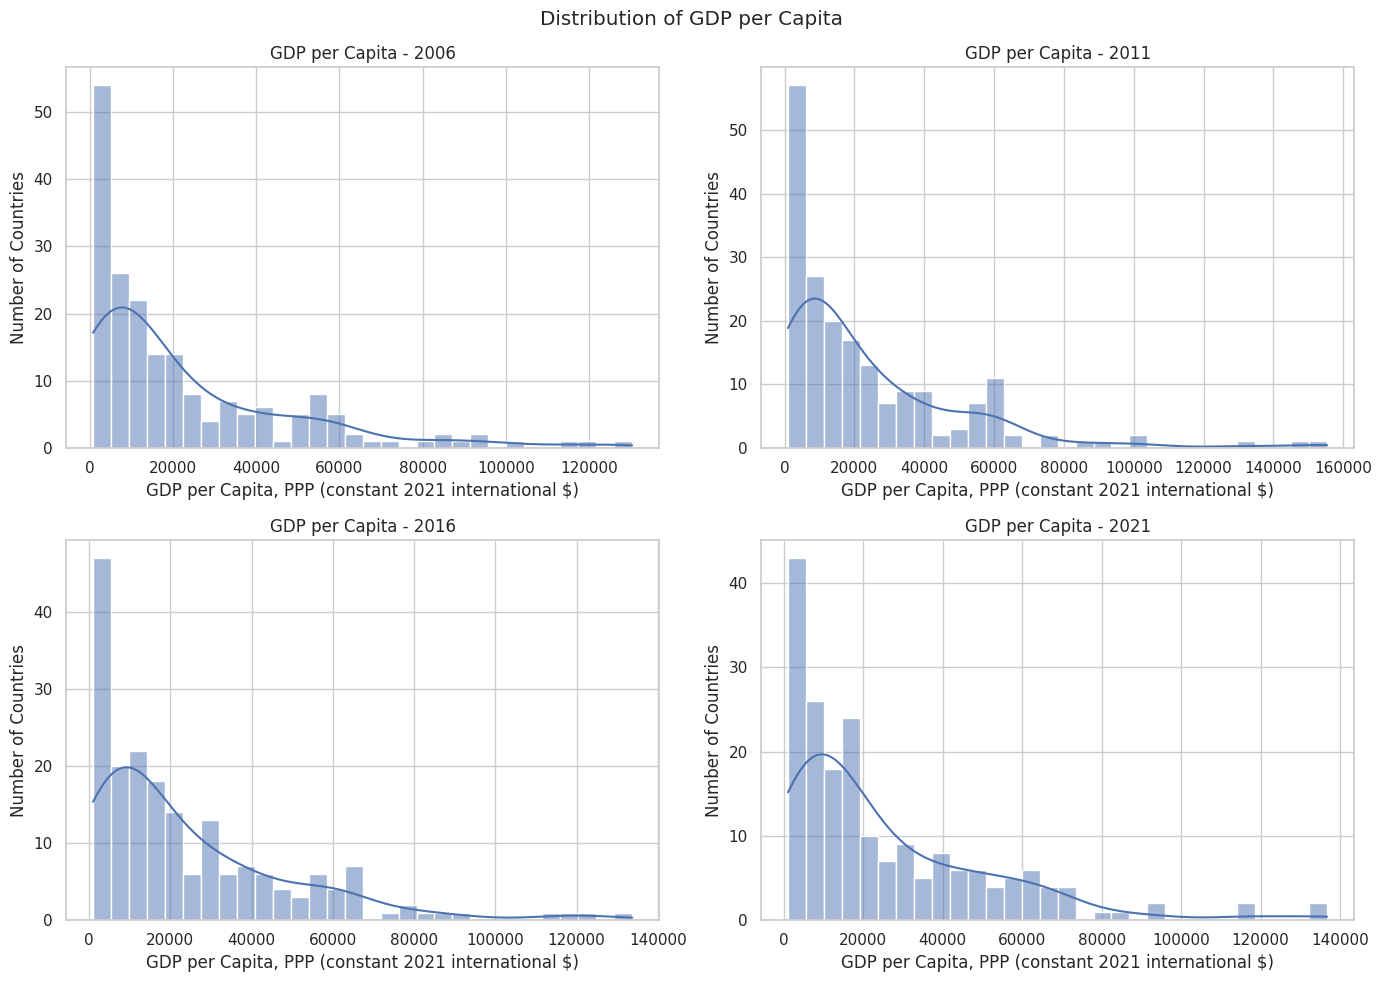

In [ ]:
# GPD per capita - Histogram (4 sub-graph 2006/2011/2016/2021)
selected_years = [2006, 2011, 2016, 2021]
sns.set_theme(style="whitegrid")
fig,axes = plt.subplots(2, 2, figsize = (14, 10))

for ax, year in zip(axes.flat, selected_years):
  yearly_data = df_final[df_final["Year"] == year]

  sns.histplot(data = yearly_data, x = "GDP per capita, PPP (constant 2021 international $)", bins = 30, kde = True, ax = ax)

  ax.set_title(f"GDP per Capita - {year}")
  ax.set_xlabel("GDP per Capita, PPP (constant 2021 international $)")
  ax.set_ylabel("Number of Countries")

plt.suptitle("Distribution of GDP per Capita")
plt.tight_layout()
plt.show()

- **Data Component**: The data we are using for the x value is the GDP per capita (continuous numerical variable) and for the y value is the number of countries (numerical variable). We do this for 4 years (temporal variable), resulting in 4 subplots.
- **Graphical Component**: For this data, we use a histogram and plot 4 subplots within the grid to show the GDP per capita for the years 2006, 2011, 2016, 2021.
- **Label Component**: The x-axis for each subplot should say "GDP per Capita, PPP (constant 2021 international $)" and the y-axis for each subplot should say "Number of Countries", with the title being "Distribution of GDP per Capita Across Countries by Year".
- **Esthetic Component**: Our plot should show the distribution between the GDP per capita and number of countries for each of the 4 years we chose to plot to help us to see how many countries have different levels of GDP per capita in each year.
- **Ethical Component**:We are only showing 4 years out of the 15 years in the dataset, so the years in between are left out. There may also be missing values for this variable, which means not every country may be represented in each subplot.

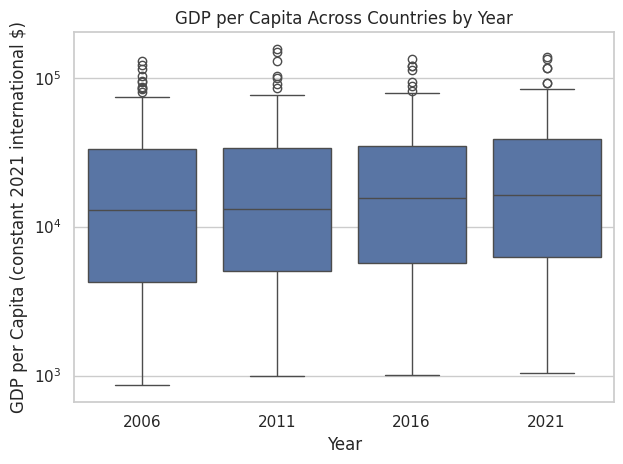

In [ ]:
# GPD per capita - Boxplot (2006/2011/2016/2021)
sns.boxplot(data = df_final[df_final["Year"].isin(selected_years)], x = "Year", y = "GDP per capita, PPP (constant 2021 international $)")

plt.yscale("log")
plt.title("GDP per Capita Across Countries by Year")
plt.xlabel("Year")
plt.ylabel("GDP per Capita (constant 2021 international $)")
plt.tight_layout()
plt.show()

- **Data Component**: The data we are using for the x value is the year (temporal variable) and for the y value is the GDP per capita (continuous numerical variable). We do this for the 4 years (temporal variable).
- **Graphical Component**: For this data, we use a boxplot to show the distribution of GDP per capita across countries for the years 2006, 2011, 2016, 2021.
- **Label Component**: The x-axis should say "Year" and the y-axis should say "GDP per Capita, PPP (constant 2021 international $)", with the title being "GDP per Capita Across Countries by Year".
- **Esthetic Component**: Our plot shows the distribution of GDP per capita across countries for each of the 4 years we chose to show the the median, spread, and potential outliers in GDP per capita for each year.
- **Ethical Component**: We are leaving out the years in between the years selected. The graph also uses a log scale, which can make differences between lower and higher GDP values easier to see but may make the values less intuitive to interpret.

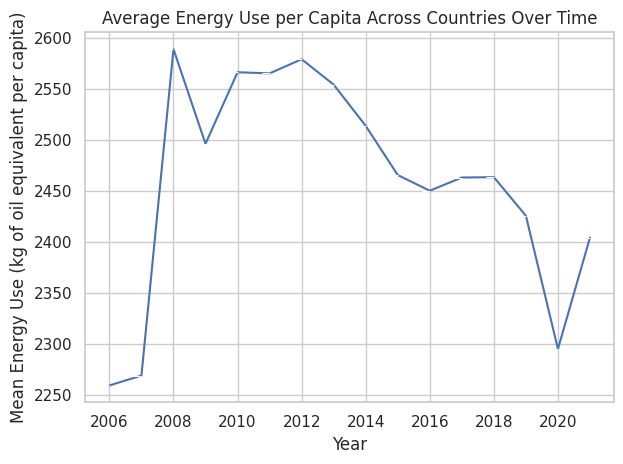

In [ ]:
# Average energy use by year - Line OR Energy use -Boxplot 2006/2011/2016/2021
energy_by_year = (df_final.groupby("Year")["Energy use (kg of oil equivalent per capita)"].mean().reset_index())

sns.lineplot(data = energy_by_year, x = "Year", y = "Energy use (kg of oil equivalent per capita)", marker = 0)

plt.title("Average Energy Use per Capita Across Countries Over Time")
plt.xlabel("Year")
plt.ylabel("Mean Energy Use (kg of oil equivalent per capita)")
plt.tight_layout()
plt.show()

- **Data Component**: The data we are using for the x value is the year (temporal variable) and for the y value is the average energy use (kg of oil equivalent per capita) (continuous numerical variable). We do this for all the years in our dataset.
- **Graphical Component**: For this data, we use a lineplot to show the change in average energy use across the countries over time.
- **Label Component**: The x-axis should say "Year" and the y-axis should say "Mean Energy Use (kg of oil equivalent per capita)", with the title being "Average Energy Use per Capita Across Countries Over Time".
- **Esthetic Component**: Our plot should show the average energy use across countries for each year in the dataset to show the overall trend in average energy use over time and whether it increases or decreases.
- **Ethical Component**: Our graph shows an overall decline in mean energy use, which may not represent every individual country because the graph only shows the average across countries. There are also missing values for this variable, so the average for each year may be based on different numbers of countries.

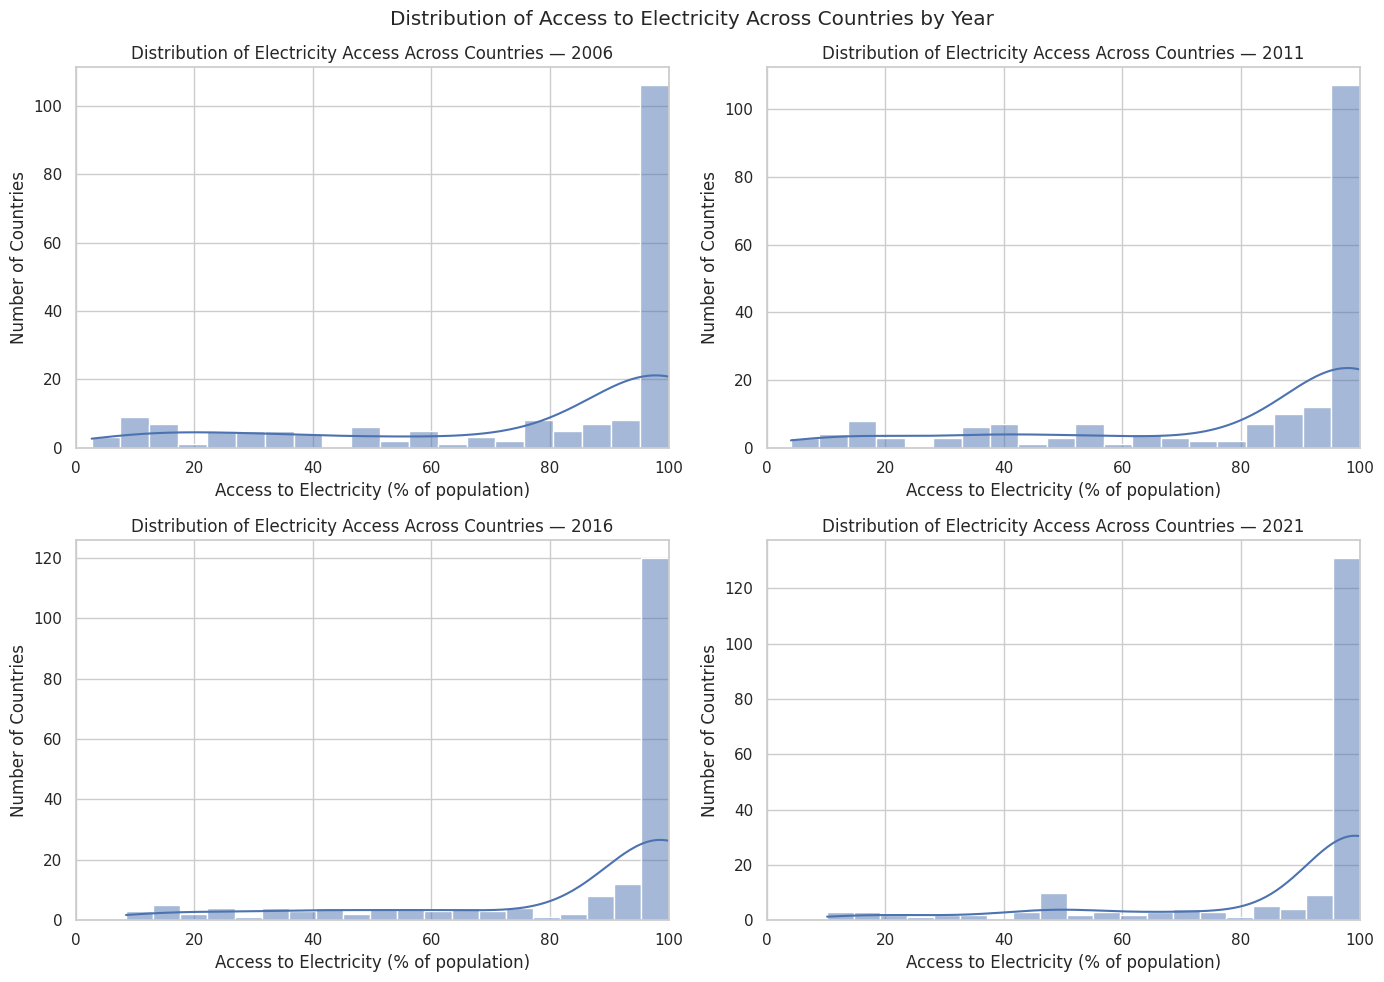

In [ ]:
# Access to electricity (% of population) - Histogram
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, year in zip(axes.flat, selected_years):
  yearly_data = df_final[df_final["Year"] == year]

  sns.histplot(data = yearly_data, x = "Access to electricity (% of population)", bins = 20, kde = True, ax = ax)

  ax.set_xlim(0, 100)

  ax.set_title(f"Distribution of Electricity Access Across Countries — {year}")
  ax.set_xlabel("Access to Electricity (% of population)")
  ax.set_ylabel("Number of Countries")

plt.suptitle("Distribution of Access to Electricity Across Countries by Year")
plt.tight_layout()
plt.show()

- **Data Component**: The data we are using for the x value is the access to electricity (% of population) (continuous numerical variable) and for the y value is the number of countries (numerical variable). We do this for the 4 years (temporal variable), resulting in 4 subplots.
- **Graphical Component**: For this data, we use a histogram and plot 4 subplots within the grid to show the access to electricity for the years 2006, 2011, 2016, 2021.
- **Label Component**: The x-axis for each subplot should say "Access to Electricity (% of population)" and the y-axis for each subplot should say "Number of Countries", with the title being "Distribution of Access to Electricity Across Countries by Year".
- **Esthetic Component**: Our plot should show the distribution between the access to electricity and number of countries for each of the 4 years we chose to plot to show how many countries have different percentages of their population with access to electricity in each year.
- **Ethical Component**: The graph only showing 4 years out of the 15 years in the dataset, so the years in between are left out. There may also be missing values for this variable, which means not every country may be represented in each subplot.

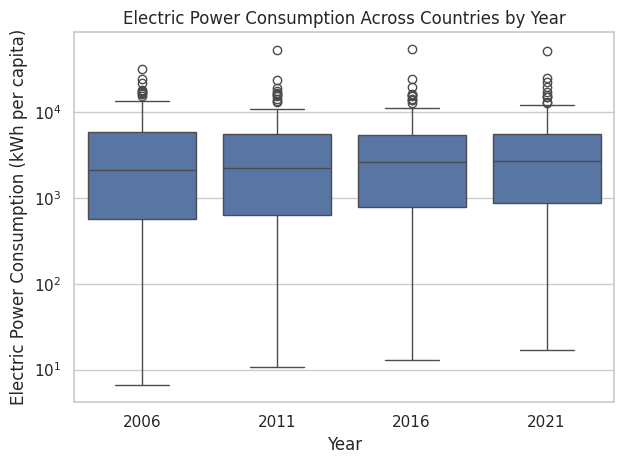

In [ ]:
# Electric power consumption (kWh per capita)
sns.boxplot(data = df_final[df_final["Year"].isin(selected_years)], x = "Year", y = "Electric power consumption (kWh per capita)")

plt.yscale("log")
plt.title("Electric Power Consumption Across Countries by Year")
plt.xlabel("Year")
plt.ylabel("Electric Power Consumption (kWh per capita)")
plt.tight_layout()
plt.show()

- **Data Component**: The data we are using for the x value is the year (temporal variable) and for the y value is the electric power consumption (kWh per capita) (continuous numerical variable). We do this for the 4 years (temporal variable).
- **Graphical Component**: For this data, we use a boxplot to show the distribution of electric power consumption across countries for the years 2006, 2011, 2016, 2021.
- **Label Component**: The x-axis should say "Year" and the y-axis should say "Electric Power Consumption (kWh per capita)", with the title being "Electric Power Consumption Across Countries by Year".
- **Esthetic Component**: Our plot should show the distribution of electric power consumption across countries for each of the 4 years we chose to plot to see the median, spread, and potential outliers for each year.
- **Ethical Component**: We are leaving out the years in between the years selected. Also, there are missing values for this variable, so not every country may be represented in each boxplot.

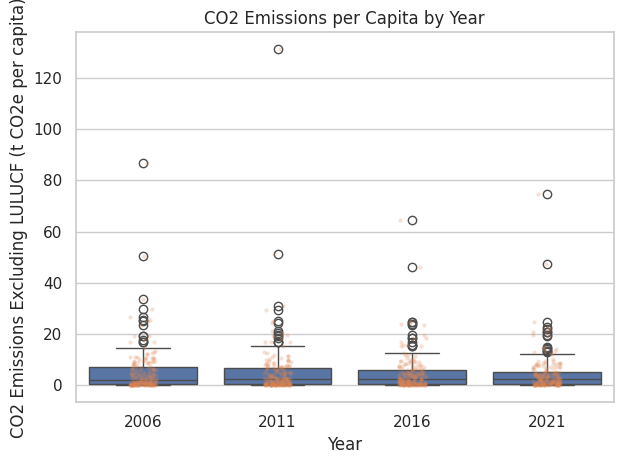

In [ ]:
# Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita) - Boxplot 2006/2011/2016/2021
sns.boxplot(data = df_final[df_final["Year"].isin(selected_years)], x = "Year", y = "Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita)")

sns.stripplot(data = df_final[df_final["Year"].isin(selected_years)], x = "Year", y = "Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita)", alpha = 0.25, size = 3)

plt.title("CO2 Emissions per Capita by Year")
plt.xlabel("Year")
plt.ylabel("CO2 Emissions Excluding LULUCF (t CO2e per capita)")
plt.tight_layout()
plt.show()

- **Data Component**: The data we are using for the x value is the year (temporal variable) and for the y value is the CO2 emissions excluding LULUCF per capita (t CO2e per capita) (continuous numerical variable). We do this for the 4 years (temporal variable).
- **Graphic Component**: For this data, we use a boxplot to show the distribution of CO2 emissions across countries for the years 2006, 2011, 2016, 2021. We also use a stripplot to show the individual countries' values within each year.
- **Label Component**: The x-axis should say "Year" and the y-axis should say "CO2 Emissions Excluding LULUCF (t CO2e per capita)", with the title being "CO2 Emissions per Capita by Year".
- **Esthetic Component**: Our plot should show the distribution of CO2 emissions across countries for each of the 4 years we chose to plot to view the median and spread, while the individual points show the values for each country.
- **Ethical Component**: Since our graph is only plotting the 4 years out of the 15 years in our dataset, we are leaving out the years in between the years selected. There are also some missing values for CO2 emissions, so some countries may not be included in the graph. The graph also does not show the causes of the differences in CO2 emissions between countries.

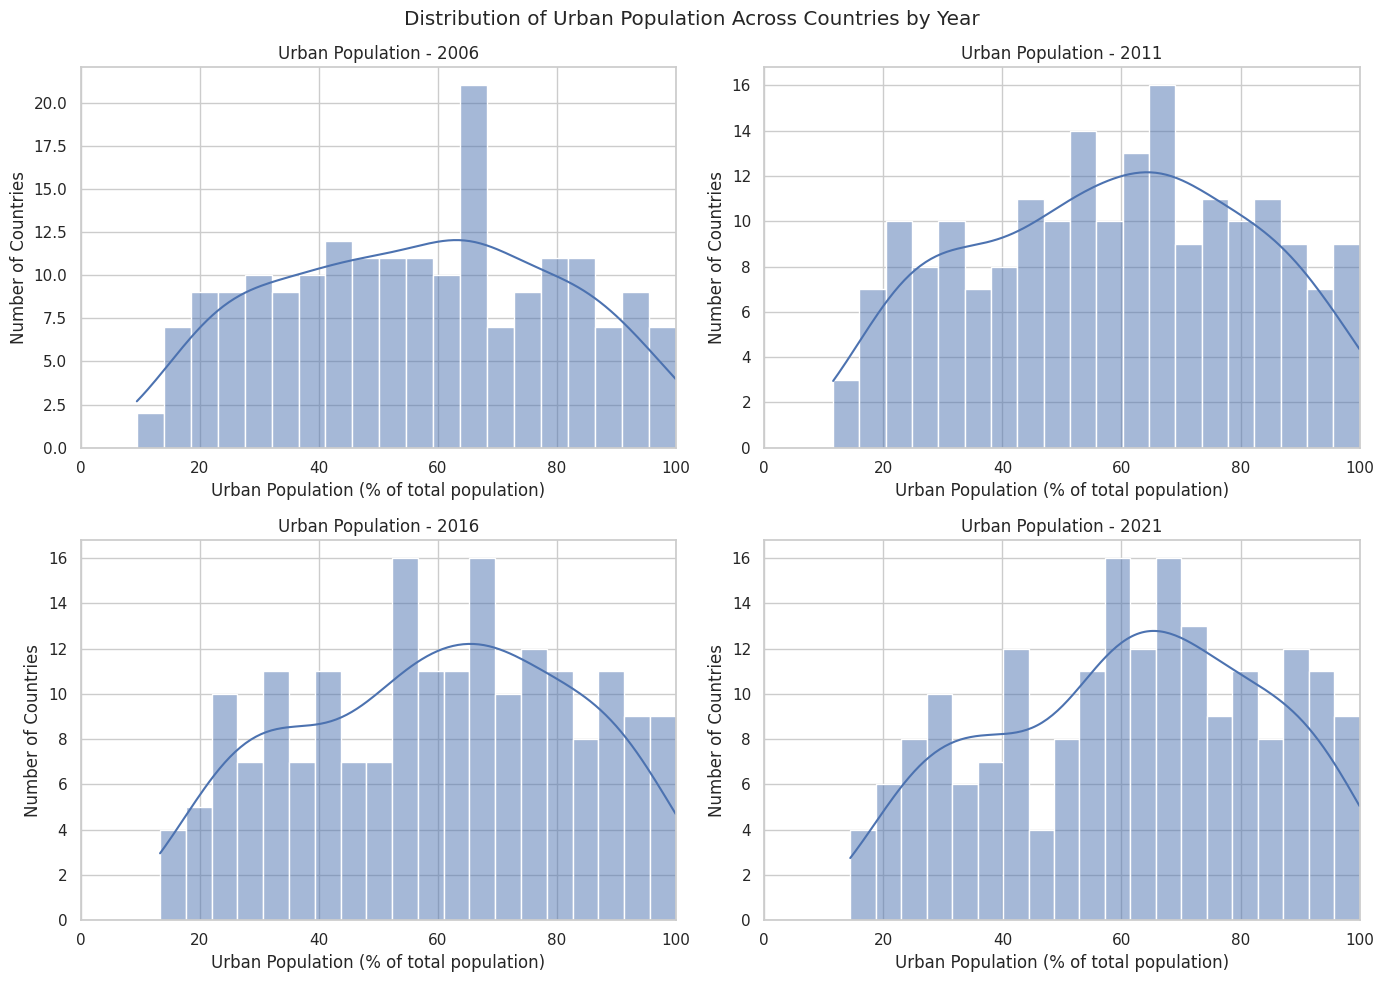

In [ ]:
# Urban population % - Histogram (4 sub-graph 2006/2011/2016/2021)
fix,axes = plt.subplots(2, 2, figsize=(14,10))

for ax, year in zip(axes.flat, selected_years):
  yearly_data = df_final[df_final["Year"] == year]

  sns.histplot(data = yearly_data, x = "Urban population (% of total population)", bins = 20, kde = True, ax = ax)

  ax.set_xlim(0, 100)
  ax.set_title(f"Urban Population - {year}")
  ax.set_xlabel("Urban Population (% of total population)")
  ax.set_ylabel("Number of Countries")

plt.suptitle("Distribution of Urban Population Across Countries by Year")
plt.tight_layout()
plt.show()

- **Data Component**: The data we are using for the x value is the urban population (% of total population) (continuous numerical variable) and for the y value is the number of countries (numerical variable). We do this for the 4 years (temporal variable), resulting in 4 subplots.
- **Graphical Component**: For this data, we use a histogram and plot 4 subplots within the grid to show the urban population for the years 2006, 2011, 2016, 2021.
- **Label Component**: The x-axis for each subplot should say "Urban Population (% of total population)" and the y-axis for each subplot should say "Number of Countries", with the title being "Distribution of Urban Population Across Countries by Year".
- **Esthetic Component**: Our plot should show the distribution between the urban population and number of countries for each of the 4 years we chose to plot to see how many countries have different percentages of their population living in urban areas.
- **Ethical Component**: The graph only shows 4 years out of the 15 years in the dataset, so the years in between are left out. The graph also does not show the total population size of each country.

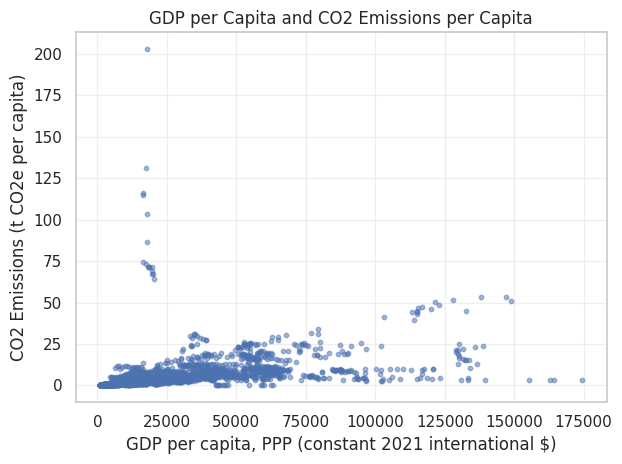

In [ ]:
# Carbon dioxide emissions per capita by GDP per capita - Scatterplot
plt.scatter(
    x=df_final["GDP per capita, PPP (constant 2021 international $)"],
    y=df_final["Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita)"], alpha=0.5, s=10)

plt.xlabel("GDP per capita, PPP (constant 2021 international $)")
plt.ylabel("CO2 Emissions (t CO2e per capita)")
plt.title("GDP per Capita and CO2 Emissions per Capita")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

- **Data Component**: The data we are using for the x value is the GDP per capita, PPP (constant 2021 international \$) (continuous numerical variable) and for the y value is the CO2 emissions excluding LULUCF per capita (t CO2e per capita) (continuous numerical variable). The data also includes country and year, which are categorical and temporal variables.
- **Graphical Component**: For this data, we use a scatterplot to show the relationship between GDP per capita and CO2 emissions per capita across the countries and years in our dataset.
- **Label Component**: The x-axis should say "GDP per capita, PPP (constant 2021 international $)" and the y-axis should say "CO2 Emissions (t CO2e per capita)", with the title being "GDP per Capita and CO2 Emissions per Capita".
- **Esthetic Component**: Our plot should show the relationship between GDP per capita and CO2 emissions per capita to see whether countries with different levels of GDP per capita also have different levels of CO2 emissions per capita.
- **Ethical Component**: This graph can make the relationship look stronger or weaker depending on the number of overlapping points. It includes multiple years for countries, so the points are not independent observations. There are also missing values for CO2 emissions.

# 4. Compute and visualize correlations
- Correct correlation
matrix or heatmap.
- Clear labeling and
formatting.

In [ ]:
# Define corr matrix
numeric_df = df_final.drop(columns=["Country Name", "Year"])
corr_matrix = numeric_df.corr()

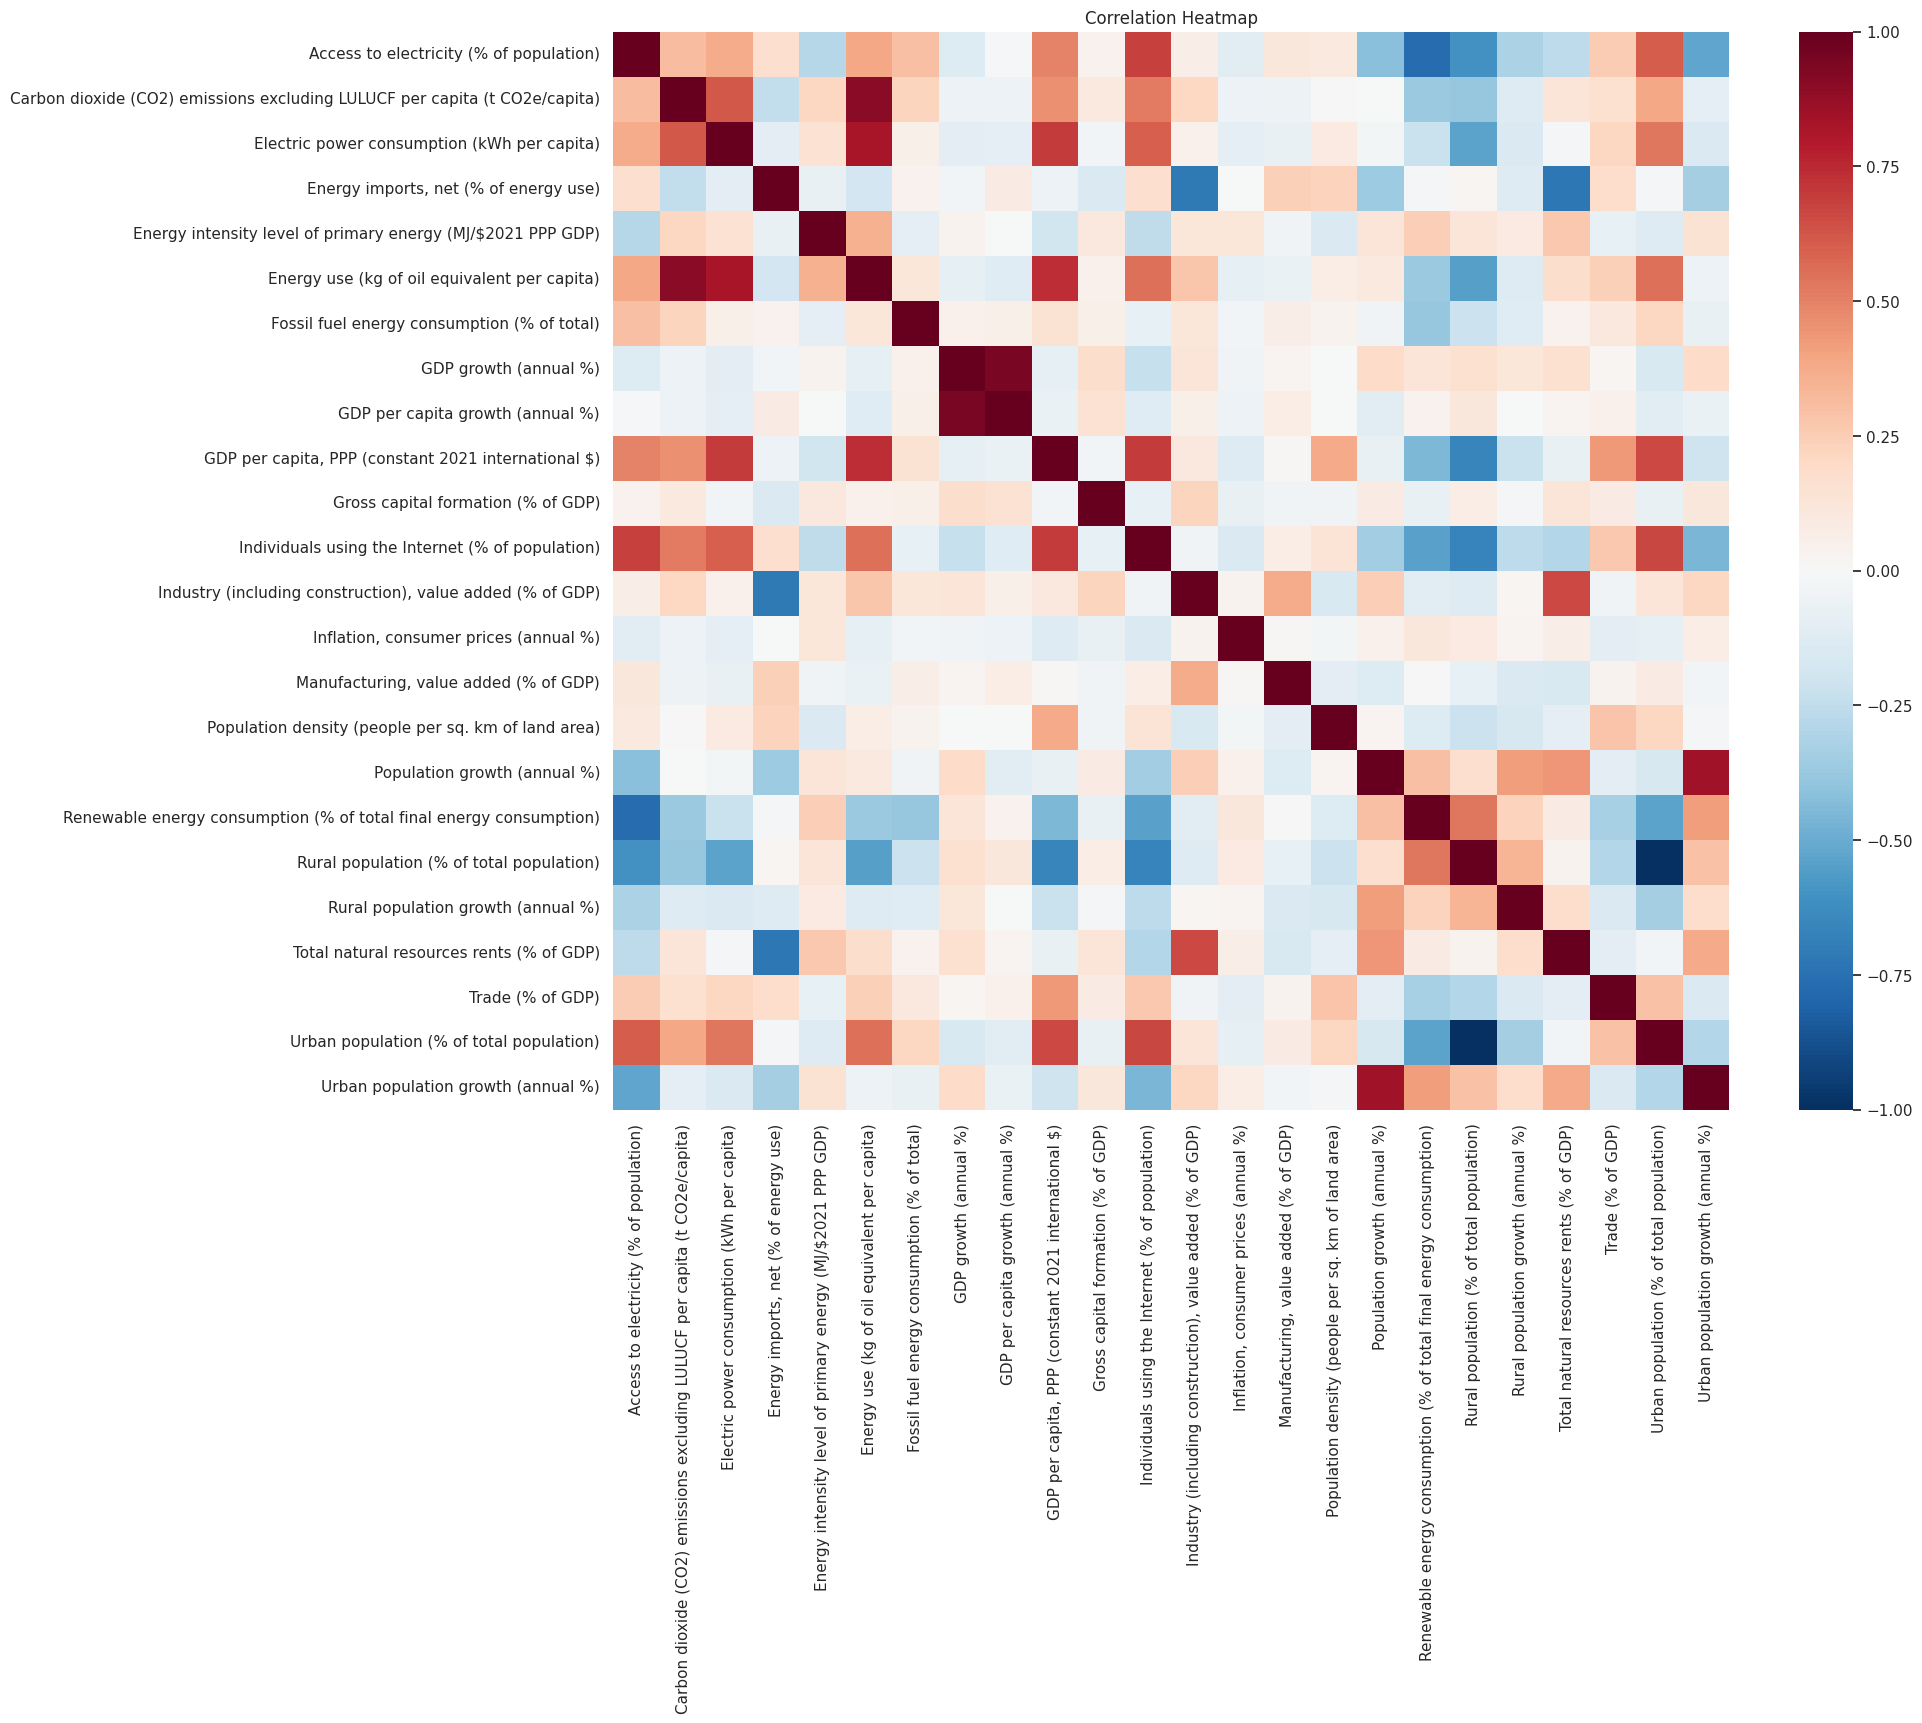

In [ ]:
# Heatmap of all variables
plt.figure(figsize=(18, 14))

sns.heatmap(corr_matrix,
            cmap="RdBu_r",  # We choose this color palette to distinguish the positive and negative values
            center=0,
            annot=False)

plt.title("Correlation Heatmap")
plt.show()

In [ ]:
# Correlation matrix - GDP vs. all numeric variables
gdp = "GDP per capita, PPP (constant 2021 international $)"

gdp_corr = (corr_matrix[gdp]
            .drop(gdp)
            .sort_values(ascending=False))  # Sort from largest to lowest

gdp_corr

,"GDP per capita, PPP (constant 2021 international $)"
Energy use (kg of oil equivalent per capita),0.735865
Individuals using the Internet (% of population),0.703111
Electric power consumption (kWh per capita),0.699756
Urban population (% of total population),0.662797
Access to electricity (% of population),0.492829
Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita),0.454350
Trade (% of GDP),0.429697
Population density (people per sq. km of land area),0.378809
Fossil fuel energy consumption (% of total),0.140930
"Industry (including construction), value added (% of GDP)",0.102258


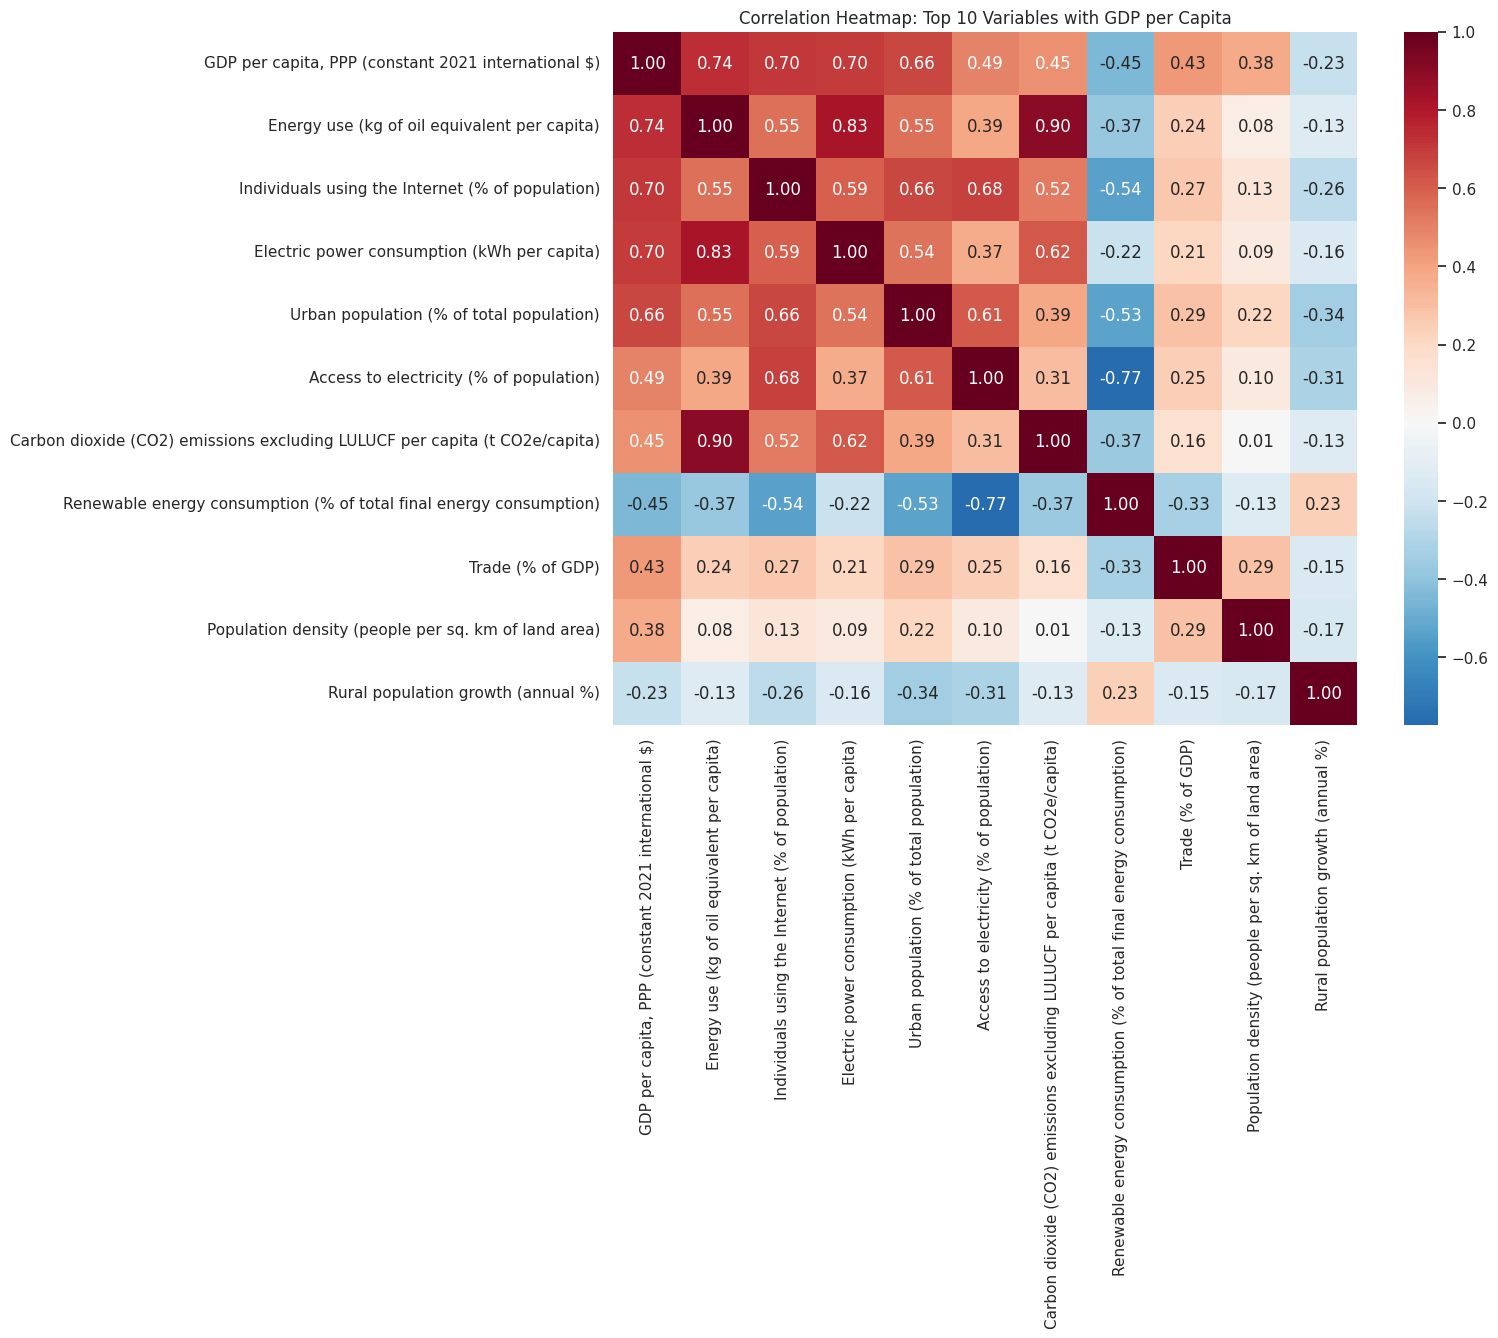

In [ ]:
# Heatmap of top 10 variables most strongly correlated with GDP based on absolute correlation
# Define top 10 variables based on absolute correlation with GDP
top_11 = (gdp_corr
          .abs()                              # We will use absolute values
          .sort_values(ascending=False)       # Sort highest to lowest
          .head(11)
          .index)                             # Only get the name, not the absolute values. We still use the original values later

# Remove Rural population because it is complementary to Urban population
top_10 = top_11.drop("Rural population (% of total population)")

# Add GDP
variables = [gdp] + list(top_10)

# Get the original correlation values of variables
top_corr = corr_matrix.loc[variables, variables]

# Heatmap
plt.figure(figsize=(12, 9))
sns.heatmap(top_corr,
            annot=True,
            fmt=".2f",
            cmap="RdBu_r",
            center=0)

plt.title("Correlation Heatmap: Top 10 Variables with GDP per Capita")
plt.show()

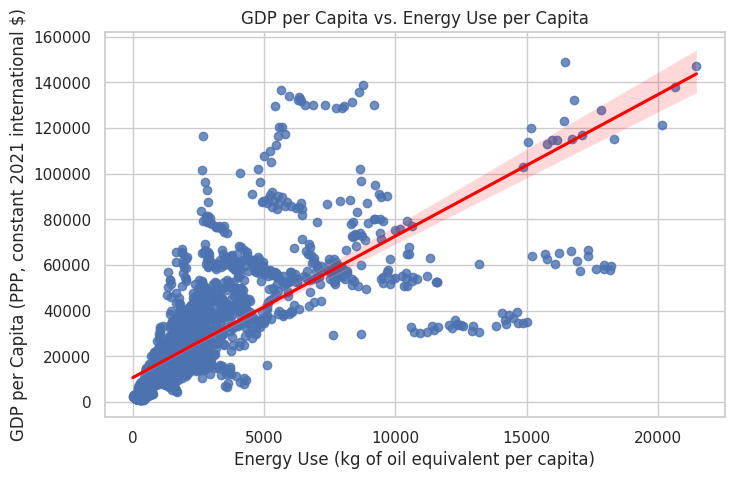

In [ ]:
#Scatter Plot: GDP per capital vs. Energy use per capital
plt.figure(figsize=(8, 5))

sns.regplot(data=df_final,
            x="Energy use (kg of oil equivalent per capita)",
            y=gdp,
            line_kws={"color": "red"})

plt.xlabel("Energy Use (kg of oil equivalent per capita)")
plt.ylabel("GDP per Capita (PPP, constant 2021 international $)")
plt.title("GDP per Capita vs. Energy Use per Capita")

plt.show()

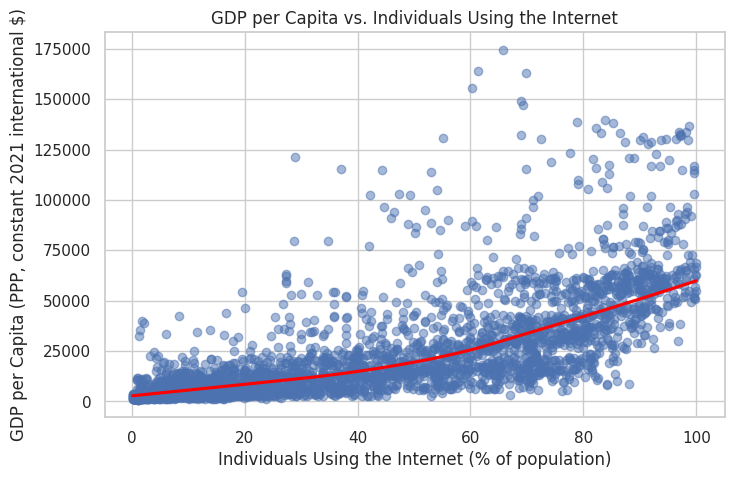

In [ ]:
#Scatter Plot: GDP per capital vs. % of individuals using the Internet
plt.figure(figsize=(8, 5))

sns.regplot(data=df_final,
            x='Individuals using the Internet (% of population)',
            y=gdp,
            lowess=True,
            scatter_kws={"alpha": 0.5},
            line_kws={"color": "red"})

plt.xlabel("Individuals Using the Internet (% of population)")
plt.ylabel("GDP per Capita (PPP, constant 2021 international $)")
plt.title("GDP per Capita vs. Individuals Using the Internet")

plt.show()

**Q2: Choose one or two correlations and describe what the magnitude and direction of the correlation suggests about the relationship between the two variables.**

Based on the correlation matrix and the heatmap above, energy use per capita and the percentage of individuals using the Internet have the strongest positive correlations with GDP per capita.

Energy use per capita has a correlation of 0.736, indicating a strong positive relationship. This suggests that countries with higher energy use per person tend to have higher GDP per capita. The percentage of individuals using the Internet has a correlation of 0.703, which also shows a strong positive relationship, suggesting that countries with higher Internet usage tend to have higher GDP per capita.

However, the scatterplots show that the patterns of these relationships are not similar. Energy use and GDP per capita show a relatively clear positive linear pattern, while Internet use and GDP per capita appear to have a more nonlinear pattern.

Note that these relationships show association, not causation.

# 5. Discussion: Did this exploritory data analysis help you better understand your chosen dataset? If so how? Is there still parts that don't make sense?
* Confirmed strong right-skew in economic variables (GDP per capita, energy use, electric power consumption) — most countries cluster at low-to-moderate values with a long tail of wealthy outliers, which justified using log scales in our boxplots.
* Identified GDP's strongest correlates: energy use (r = 0.74), internet usage (r = 0.70), electricity access (r = 0.49), and urban population (r = 0.66) — giving us a shortlist of plausible predictors for the ML stage.
* Revealed that these top predictors are highly collinear with each other (not just with GDP), which will need to be accounted for in feature selection for the prediction model.
* Showed that some relationships are non-linear: energy use vs. GDP looks roughly linear, while internet use vs. GDP is clearly curved/logistic-shaped — a plain correlation coefficient alone would have hidden this difference.
* Surfaced a counter-intuitive pattern: renewable energy share correlates negatively with GDP and electricity access, suggesting it reflects countries still building out grid infrastructure rather than "cleaner, richer" economies — a hypothesis we wouldn't have generated from summary statistics alone.//maybe we can remove this? - noor  

Are there still parts that don't make sense?

* The average energy-use-per-capita line shows an unexplained jump between 2007 and 2008 and a dip around 2020 — likely driven by which countries had reported data that year rather than a genuine global shift; we haven't yet confirmed this by checking country counts per year.
* A small cluster of countries sits far above the general trend in the GDP-vs-CO2 scatterplot (CO2 per capita of 70–200+ at moderate GDP levels) — these are almost certainly small oil/gas-exporting states, but we haven't identified them by name or decided whether to treat them as outliers or a distinct group.
* We have to investigate whether missingness is random or systematic (e.g., whether lower-income countries are underrepresented in earlier years), which could bias the correlations toward wealthier, better-reported countries.

Dataset limitations: This the dataset has missing values for some indicators and countries, particularly for energy-related variables. The original World Bank dataset was not analysis-ready, so we reformatted it from multiple-year columns to a country-year format. During this process, we also limited the analysis to 2006–2021, as data availability decreased significantly after 2021. These factors may reduce the number of observations in certain analyses.